In [53]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## ShallowLearn Specific imports

In [54]:
from ShallowLearn.api_download import get_credentials
import ShallowLearn.QuickLook as qck_lk
import ShallowLearn.ExtractMetadata as parse_metadata
import ShallowLearn.Util as util
import ShallowLearn.API_Utils as api_utils

## Standard imports

In [55]:
import pandas as pd
import matplotlib.pyplot as plt

from datetime import date
from shapely.geometry import box
import os
import requests

## cdsetool Specific imports

In [56]:
from cdsetool.query import query_features, shape_to_wkt
from cdsetool.credentials import Credentials
from cdsetool.download import download_features
from cdsetool.monitor import StatusMonitor
from cdsetool.query import describe_collection

In [57]:
search_terms = describe_collection("Sentinel2").keys()

## Helper function to generate features from bbox 

In [58]:
features = api_utils.generate_query("55LCD")

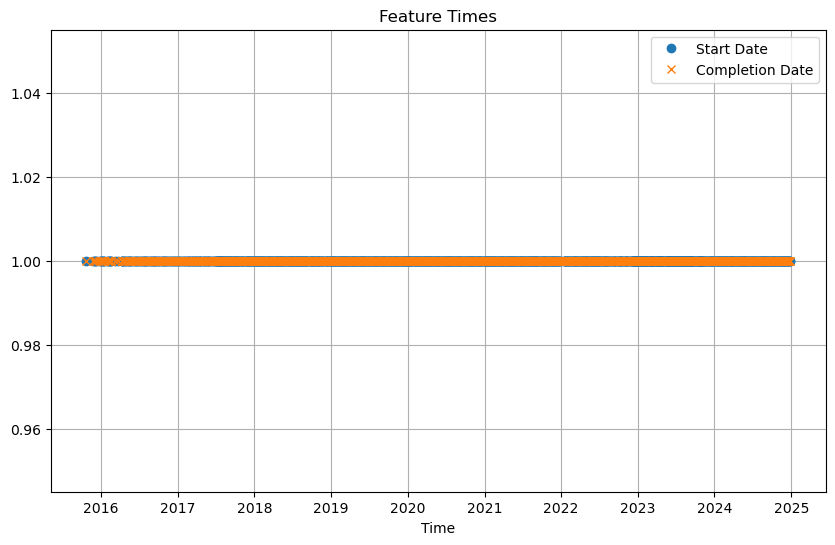

,id,startDate,completionDate,cloudCover,processingBaseline,title
0,35e8ca60-9f18-4898-9587-8ddb2892ad41,2024-07-26 00:27:11.024000+00:00,2024-07-26 00:27:11.024000+00:00,99.865150,5.11,S2A_MSIL1C_20240726T002711_N0511_R016_T55LCD_2...
1,b9461255-1b87-4cd5-bb9b-d1282ddd12ad,2024-08-28 00:37:01.024000+00:00,2024-08-28 00:37:01.024000+00:00,37.791275,5.11,S2A_MSIL1C_20240828T003701_N0511_R059_T55LCD_2...
2,33f52b7f-ec60-4dfa-ac27-55fc0d45b43c,2024-08-20 00:27:09.024000+00:00,2024-08-20 00:27:09.024000+00:00,24.972216,5.11,S2B_MSIL1C_20240820T002709_N0511_R016_T55LCD_2...
3,25ee9d8e-1d5c-4810-b8fb-9085093a4344,2024-08-10 00:27:09.024000+00:00,2024-08-10 00:27:09.024000+00:00,16.731056,5.11,S2B_MSIL1C_20240810T002709_N0511_R016_T55LCD_2...
4,3a0e754d-0d12-415f-b76a-fae904f6f049,2024-09-12 00:37:09.024000+00:00,2024-09-12 00:37:09.024000+00:00,32.167607,5.11,S2B_MSIL1C_20240912T003709_N0511_R059_T55LCD_2...
...,...,...,...,...,...,...
1285,575d0af5-d3de-5953-8c5d-e4b6b669d00c,2021-12-24 00:26:59.024000+00:00,2021-12-24 00:26:59.024000+00:00,73.688390,5.00,S2B_MSIL1C_20211224T002659_N0500_R016_T55LCD_2...
1286,c626c7c0-389b-591b-9ccd-dd70f3abaaf9,2021-12-07 00:36:59.024000+00:00,2021-12-07 00:36:59.024000+00:00,36.925378,5.00,S2B_MSIL1C_20211207T003659_N0500_R059_T55LCD_2...
1287,c7cee624-fbf5-5139-8d19-05a87dbc123c,2021-12-04 00:27:09.024000+00:00,2021-12-04 00:27:09.024000+00:00,99.992957,5.00,S2B_MSIL1C_20211204T002709_N0500_R016_T55LCD_2...
1288,d1bf8e58-41d9-5025-a34c-d461925f2b2b,2021-11-29 00:27:11.024000+00:00,2021-11-29 00:27:11.024000+00:00,29.771994,5.00,S2A_MSIL1C_20211129T002711_N0500_R016_T55LCD_2...


In [59]:
api_utils.plot_sentinel_features(features)

#### Temp Save Directory
##### If you havent previously downloaded the thumbnails set download to true

In [60]:
thumbnail_dir = "/mnt/sda_mount/Additional_Experiments/thumbnails/"

##### Limit to one orbit 

In [69]:
features = [i for i in features if "R059"  in i['properties']['title'] ]

In [70]:
pvi_api = qck_lk.QuickLookAPIPVI(features, thumbnail_dir, download_thumbnails=False);


In [71]:
class_dict = pvi_api.class_dict


#### Class dict is a dictionary estimate based on where we would expect the imagery to plot (based on expected PC space / cluster locations)

In [72]:
class_dict

{-1: ('#1f77b4', 'Partially Cloudy'),
 2: ('#d62728', 'No Data'),
 0: ('#ff7f0e', 'Clear Sky'),
 1: ('#2ca02c', 'Opaque Clouds')}

### Tune eps/samples to optimize number of images

In [75]:
pvi_api.predict(pvi_api.transformed_data, eps = 70, min_samples=10);

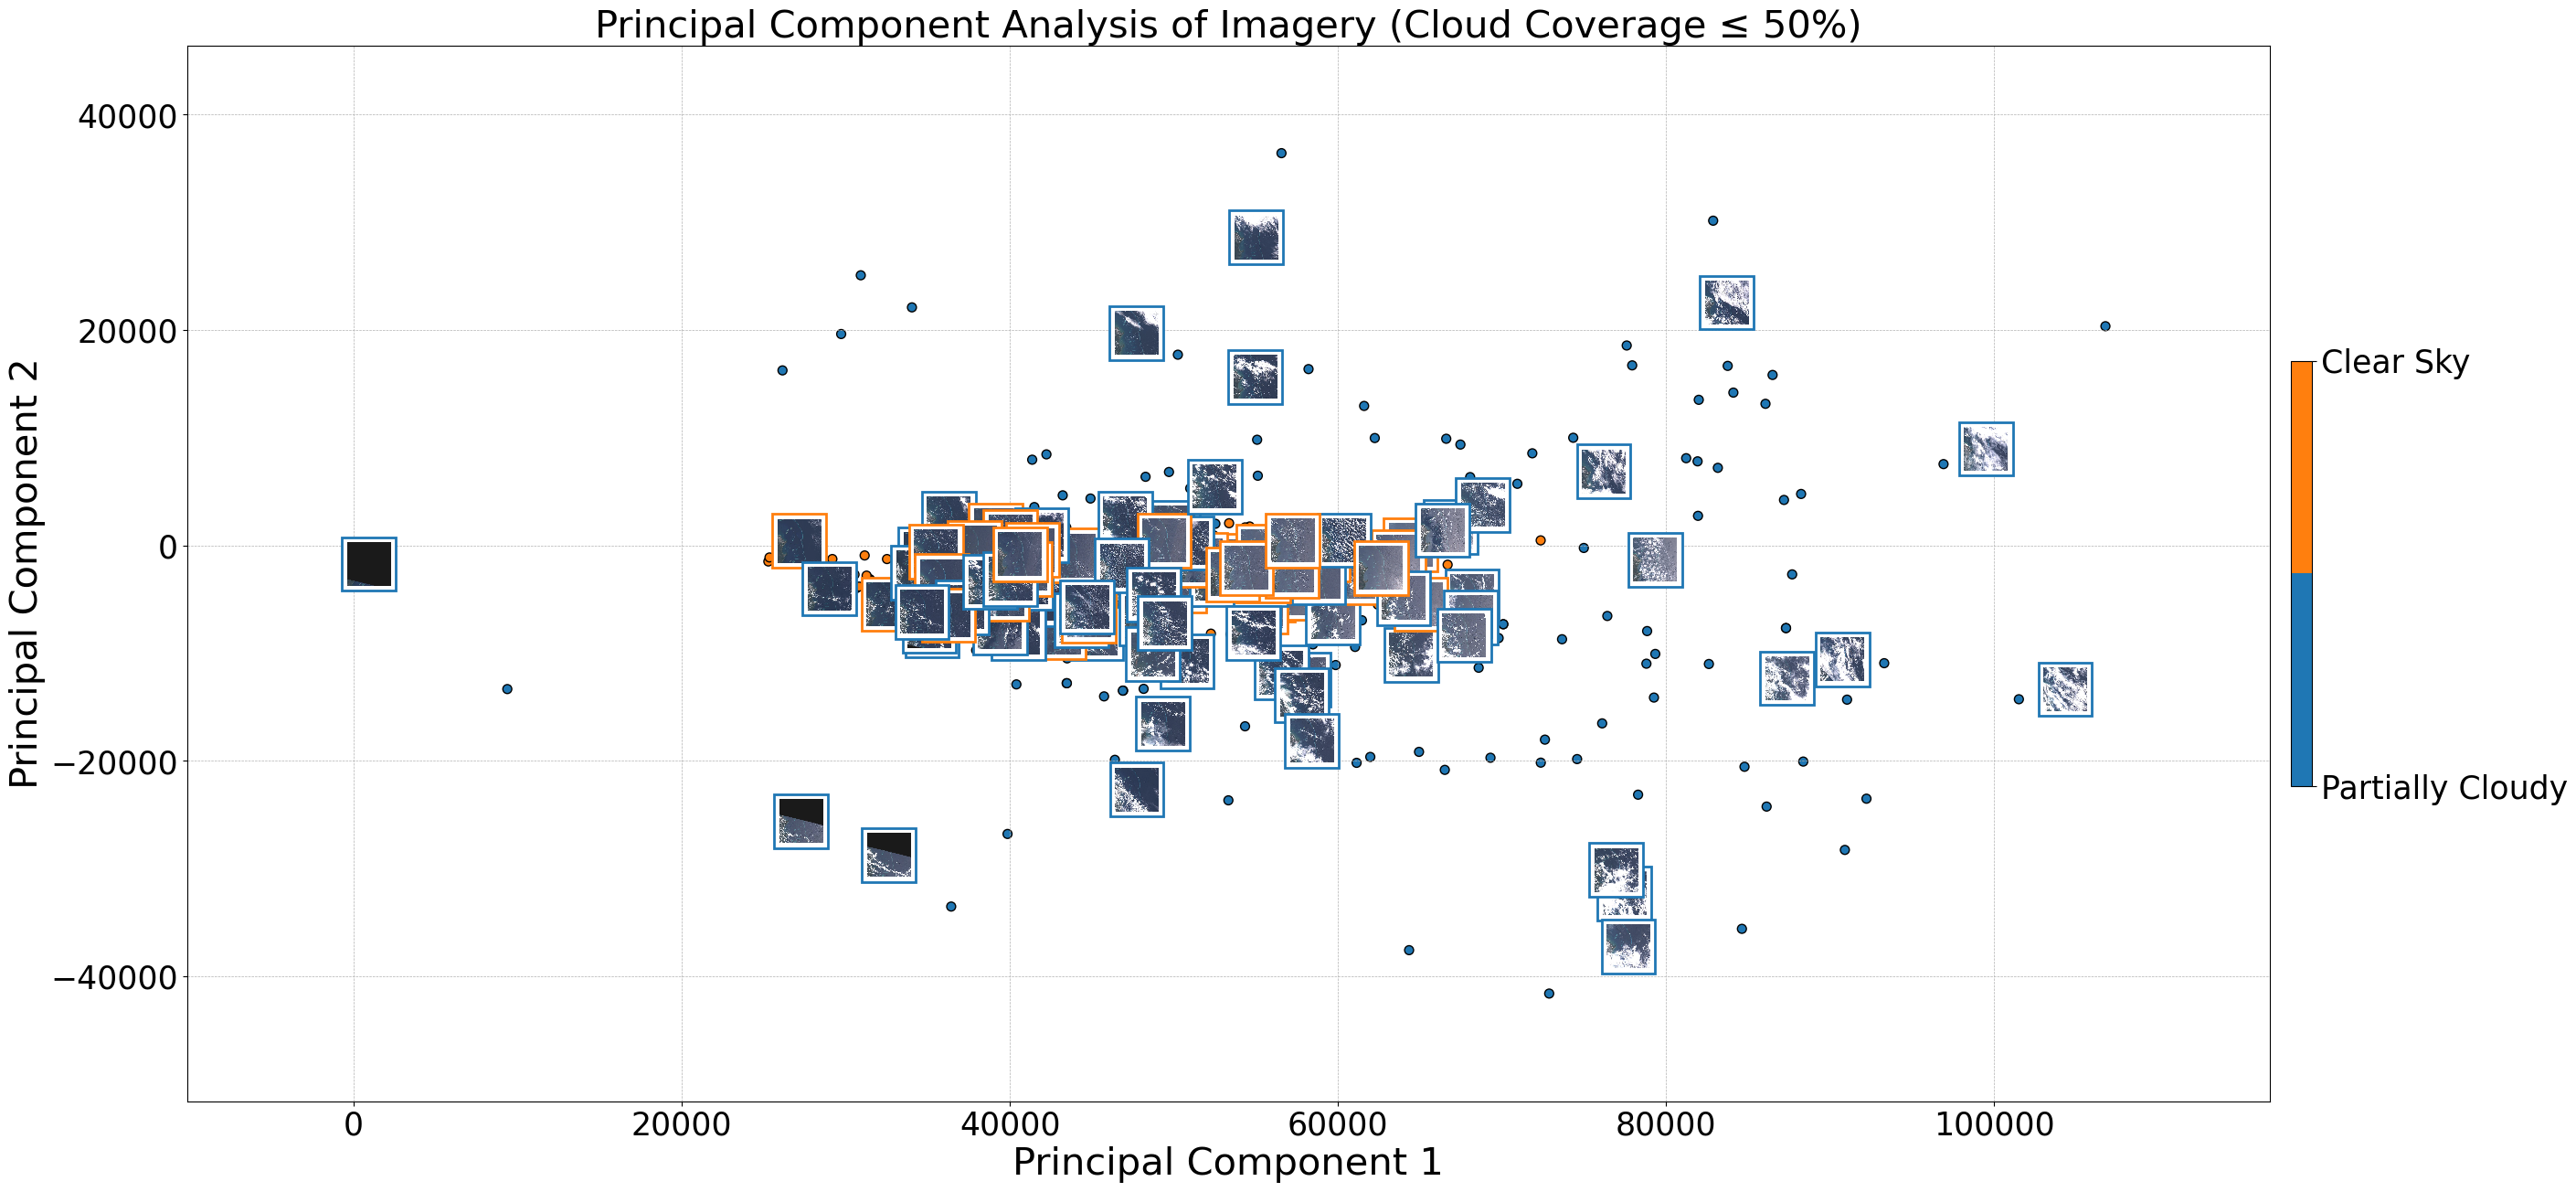

In [76]:
fig, ax = plt.subplots(1,1, figsize = (30, 15))
pvi_api.plot_principal_components(pvi_api.column_updated_df, zoom = 0.1, cloud_threshold = 50,class_dict=class_dict, ax = ax , plot_meshgrid = False)

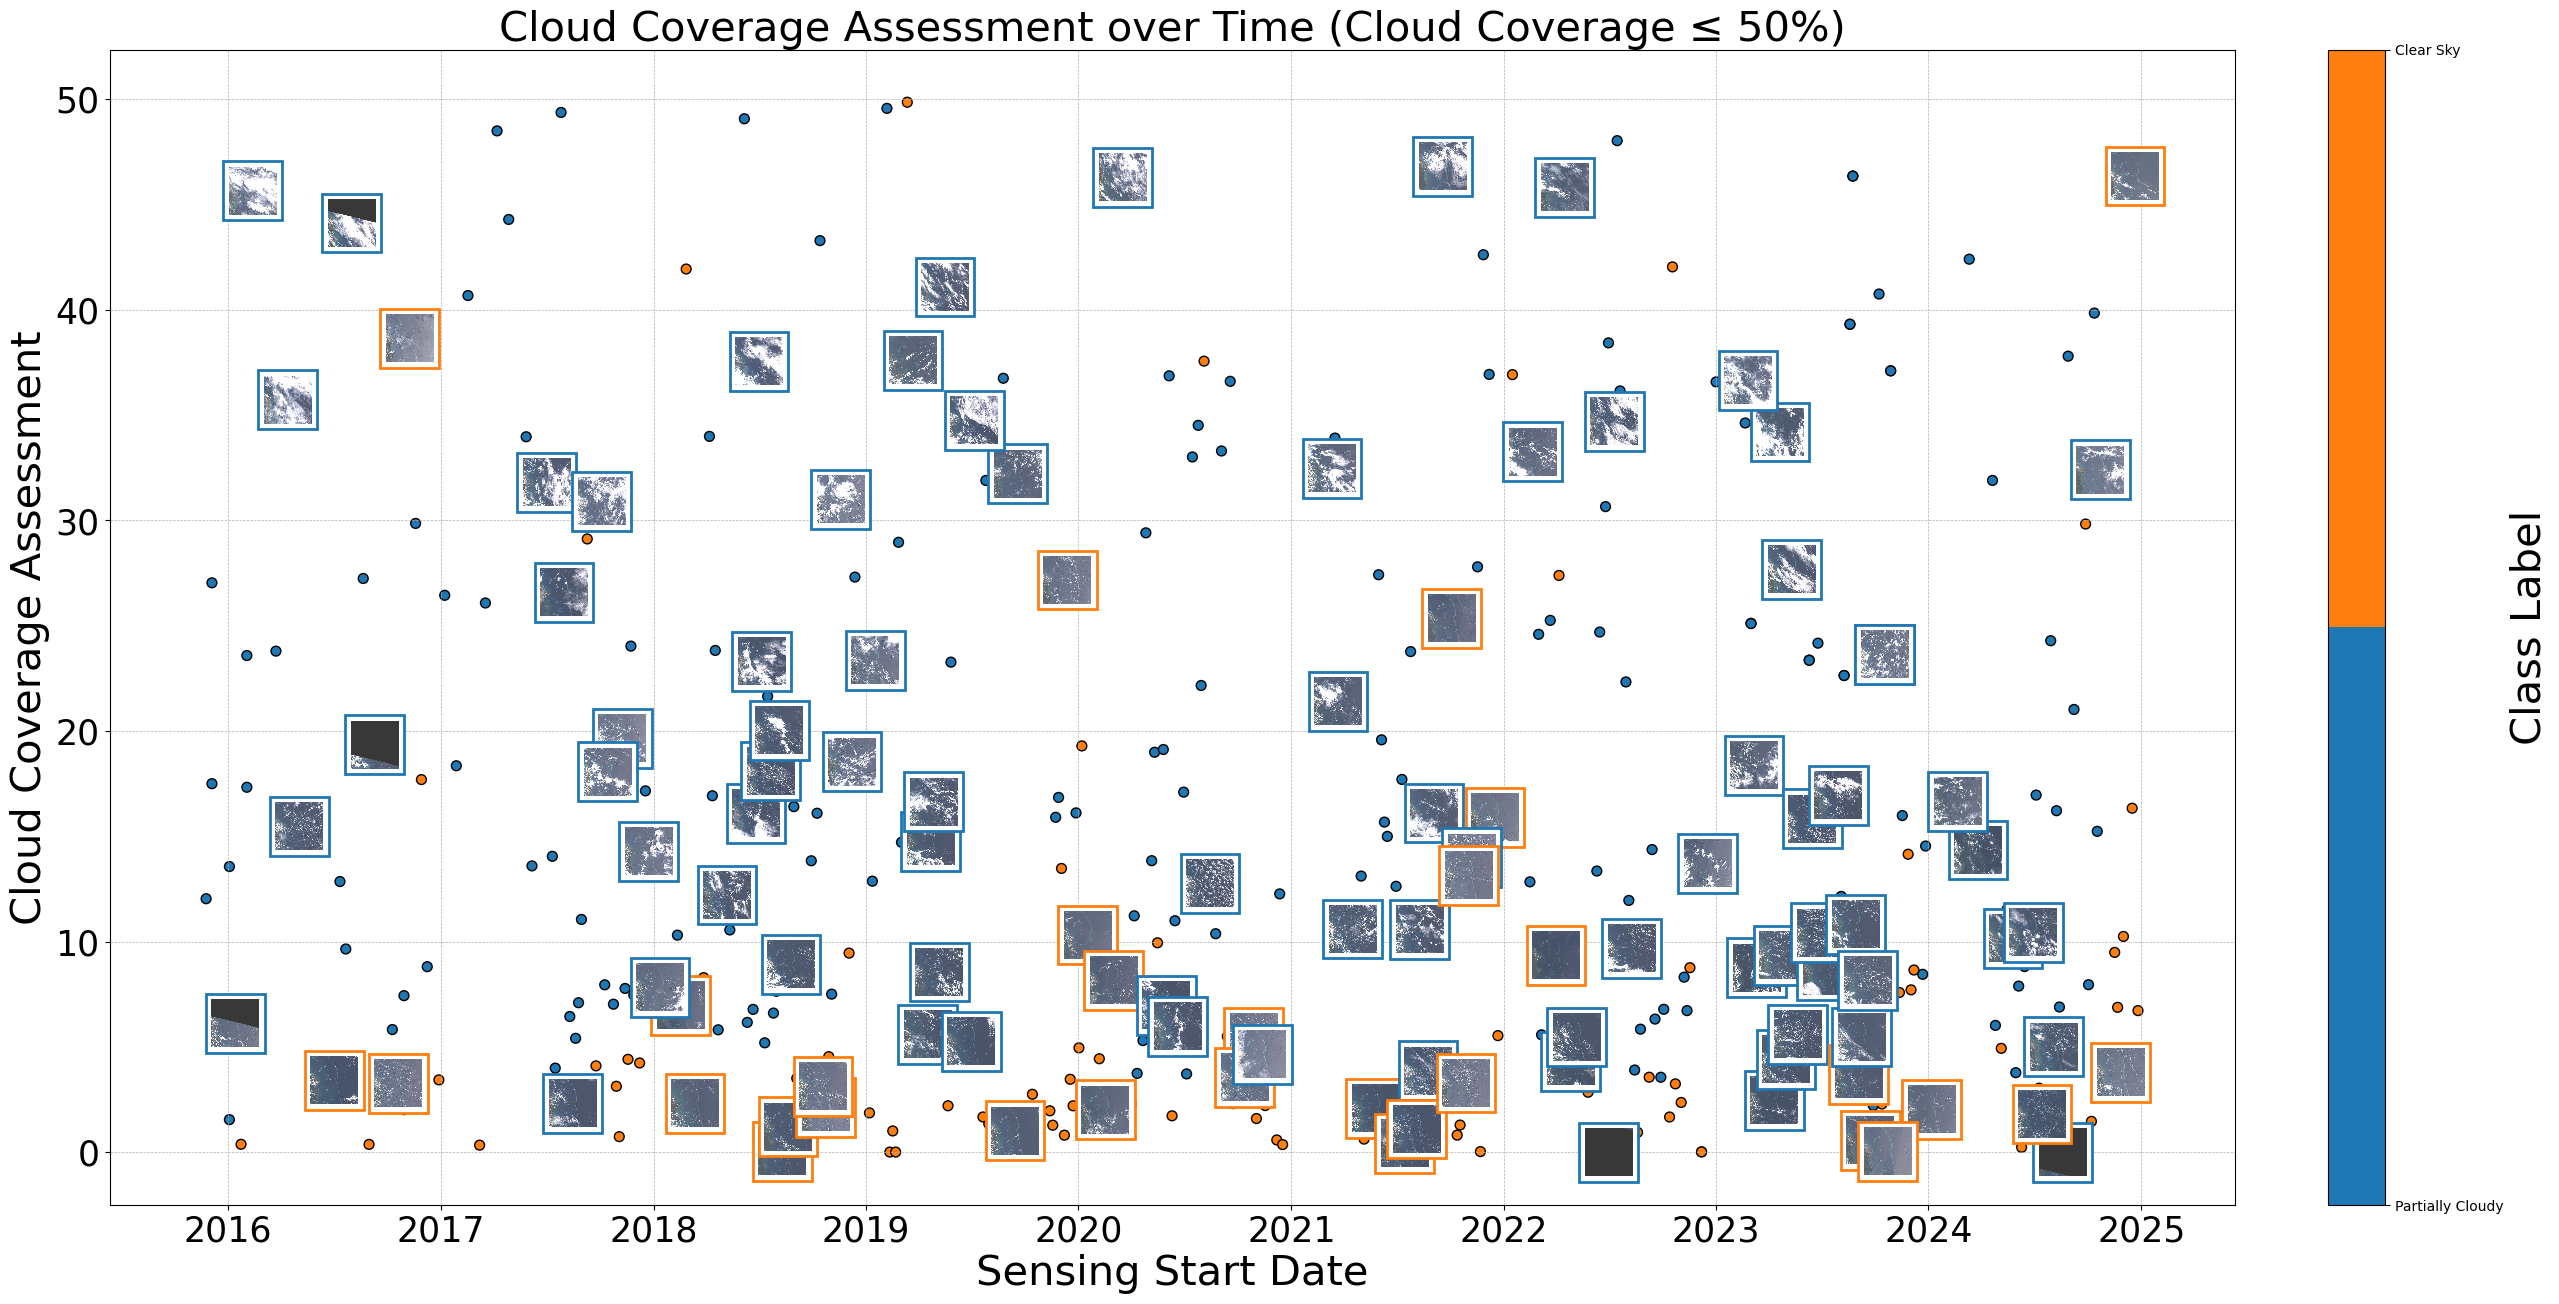

In [77]:
fig, ax = plt.subplots(1,1, figsize = (30, 15))
pvi_api.plot_cloud_coverage(pvi_api.column_updated_df, zoom = 0.1, cloud_threshold = 50,class_dict = class_dict, ax = ax)

### Finally return the query in the format needed for the ESA API

In [ ]:
pvi_api.get_cloud_free_dataset()

In [ ]:
api_utils.plot_sentinel_features(pvi_api.get_cloud_free_dataset())

## Helper function with environment variables containing ESA user/pass combo

In [ ]:
creds = get_credentials()

#### Now just download the data normally to some path

In [ ]:
save_path = "Some_Directory"

In [ ]:

list(
    download_features(
        features,
        save_path,
        {
            "concurrency": 4,
            "monitor": StatusMonitor(),
            "credentials": Credentials(creds['sentinel_username'], creds['sentinel_password']),
            
        },
    )
)